In [30]:
!pip install -q --upgrade transformers

In [31]:
import torch
import torch.nn.functional as F

import numpy as np
import matplotlib.pyplot as plt

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

from scipy.stats import norm
from transformers import AutoTokenizer, AutoModelForCausalLM

from sentence_transformers import SentenceTransformer
from datasets import load_dataset

import tqdm

import warnings
warnings.filterwarnings('ignore')

In [32]:
device = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen3.5-0.8B-Base")
model_a = AutoModelForCausalLM.from_pretrained("Qwen/Qwen3.5-0.8B-Base", torch_dtype=torch.float16, device_map="auto")
model_b = AutoModelForCausalLM.from_pretrained("Qwen/Qwen3.5-2B-Base", torch_dtype=torch.float16, device_map="auto")


Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

# Embed

In [33]:
encoder = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
# dataset = load_dataset("wikimedia/wikipedia", "20231101.en", split="train", streaming=True)
# texts = [example["text"] for example in dataset.take(2000)]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [34]:
import itertools
import pandas as pd
from datasets import load_dataset

N = 500          # текстов на домен
SEED = 42
texts, domains = [], []

def add(domain, items):
    items = [t.strip() for t in items if t and len(t.strip()) > 30]
    texts.extend(items)
    domains.extend([domain] * len(items))

# news
ds = load_dataset("ag_news", split="train").shuffle(seed=SEED)
add("news", [r["text"] for r in ds.select(range(N))])

# code (сырой python как префикс)
ds = load_dataset("mbpp", split="train").shuffle(seed=SEED)
add("code", [r["code"] for r in ds.select(range(min(N, len(ds))))])

# math
ds = load_dataset("gsm8k", "main", split="train").shuffle(seed=SEED)
add("math", [r["question"] for r in ds.select(range(N))])

# wiki / general (streaming, датасет огромный — только islice)
ds = load_dataset("wikimedia/wikipedia", "20231101.en", split="train", streaming=True)
add("wiki", [r["text"][:800] for r in itertools.islice(ds, N)])

# toxic / safety
ds = load_dataset("allenai/real-toxicity-prompts", split="train", streaming=True)
add("toxic", [r["prompt"]["text"] for r in itertools.islice(ds, N)])

# chat / instructions
ds = load_dataset("tatsu-lab/alpaca", split="train").shuffle(seed=SEED)
add("chat", [r["instruction"] + (" " + r["input"] if r["input"] else "")
             for r in ds.select(range(N))])

df = pd.DataFrame({"text": texts, "domain": domains})
texts, dom_labels = df["text"].tolist(), df["domain"].tolist()

Resolving data files:   0%|          | 0/41 [00:00<?, ?it/s]

In [35]:
embeddings = encoder.encode(texts, show_progress_bar=True)
embeddings = embeddings / np.linalg.norm(embeddings, axis=1, keepdims=True) # нормализация по L2
embeddings.shape

Batches:   0%|          | 0/90 [00:00<?, ?it/s]

(2856, 384)

# Divergence

In [36]:
def truncated_jsd(logits_a: torch.Tensor, logits_b: torch.Tensor, k=30, temp=1.0) -> float:
    p = F.softmax(logits_a / temp, dim=-1)
    q = F.softmax(logits_b / temp, dim=-1)
    
    topk_a = torch.topk(p, k).indices
    topk_b = torch.topk(q, k).indices
    support = torch.unique(torch.cat([topk_a, topk_b]))
    
    p_s = p[support]
    q_s = q[support]
    
    p_s = p_s / p_s.sum()
    q_s = q_s / q_s.sum()
    
    m = 0.5 * (p_s + q_s)
    eps = 1e-12
    
    kl_pm = (p_s * torch.log((p_s + eps) / (m + eps))).sum()
    kl_qm = (q_s * torch.log((q_s + eps) / (m + eps))).sum()
    
    jsd = 0.5 * (kl_pm + kl_qm)
    return jsd.item()


def compute_divergence(model_a, model_b, tokenizer, text: str, k=30, temp=1.0) -> float:
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512)
    input_ids = inputs.input_ids.to(model_a.device)
    
    with torch.no_grad():
        outputs_a = model_a(input_ids)
        outputs_b = model_b(input_ids)
        
        logits_a = outputs_a.logits[0, -1, :]
        logits_b = outputs_b.logits[0, -1, :]
    
    return truncated_jsd(logits_a.float(), logits_b.float(), k=k, temp=temp)

# def compute_divergence(model_a, model_b, tokenizer, text, L=16, k=30):
#     ids = tokenizer(text, return_tensors="pt", truncation=True,
#                     max_length=512).input_ids.to(model_a.device)
#     with torch.no_grad():
#         la = model_a(ids).logits[0].float()
#         lb = model_b(ids).logits[0].float()
#     T = la.shape[0]
#     ds = [truncated_jsd(la[t], lb[t], k=k) for t in range(max(0, T - L), T)]
#     return float(np.mean(ds))

In [37]:
test_text = "The capital of France is"
test_div = compute_divergence(model_a, model_b, tokenizer, test_text)
test_div

0.06293781101703644

# Clustering

In [38]:
n_clusters = 6
points_per_cluster = 20

kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
kmeans.fit(embeddings)

initial_indices = []
for i in range(n_clusters):
    cluster_points = np.where(kmeans.labels_ == i)[0]
    if len(cluster_points) == 0:
        continue
    centroid = kmeans.cluster_centers_[i]
    distances = np.linalg.norm(embeddings[cluster_points] - centroid, axis=1)
    
    k = min(points_per_cluster, len(cluster_points))
    top_k_local = np.argsort(distances)[:k]
    initial_indices.extend(cluster_points[top_k_local])

    k = min(points_per_cluster, len(cluster_points))
    medoid = cluster_points[np.argmin(distances)]
    rest = np.setdiff1d(cluster_points, [medoid])
    extra = np.random.choice(rest, size=k - 1, replace=False) if len(rest) >= k - 1 else rest
    initial_indices.extend([medoid] + list(extra))

initial_indices = np.array(sorted(initial_indices))

In [39]:
initial_divergences = []
for idx in tqdm.tqdm(initial_indices):
    text = texts[idx]
    div = compute_divergence(model_a, model_b, tokenizer, text)
    initial_divergences.append(div)

initial_divergences = np.array(initial_divergences)

100%|██████████| 240/240 [01:42<00:00,  2.34it/s]


# GP

In [40]:
kernel = RBF(length_scale=0.5, length_scale_bounds=(0.1, 2.0))

gp = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,
    n_restarts_optimizer=5,
    random_state=42
)

In [41]:
X_train = embeddings[initial_indices]
y_train = initial_divergences

In [42]:
gp.fit(X_train, y_train)
mu_all, sigma_all = gp.predict(embeddings, return_std=True)

In [43]:
# tsne = TSNE(n_components=2, random_state=42, perplexity=30)
# embeddings_2d = tsne.fit_transform(embeddings)

In [44]:
import umap

reducer = umap.UMAP(
    n_components=2,      # Целевая размерность (обычно 2 для визуализации)
    n_neighbors=15,      # Баланс между локальной и глобальной структурой
    min_dist=0.1,        # Насколько плотно точки прижимаются друг к другу
    metric='euclidean',  # Метрика расстояния
    random_state=42
)

# 3. Понижение размерности
embeddings_2d = reducer.fit_transform(embeddings)

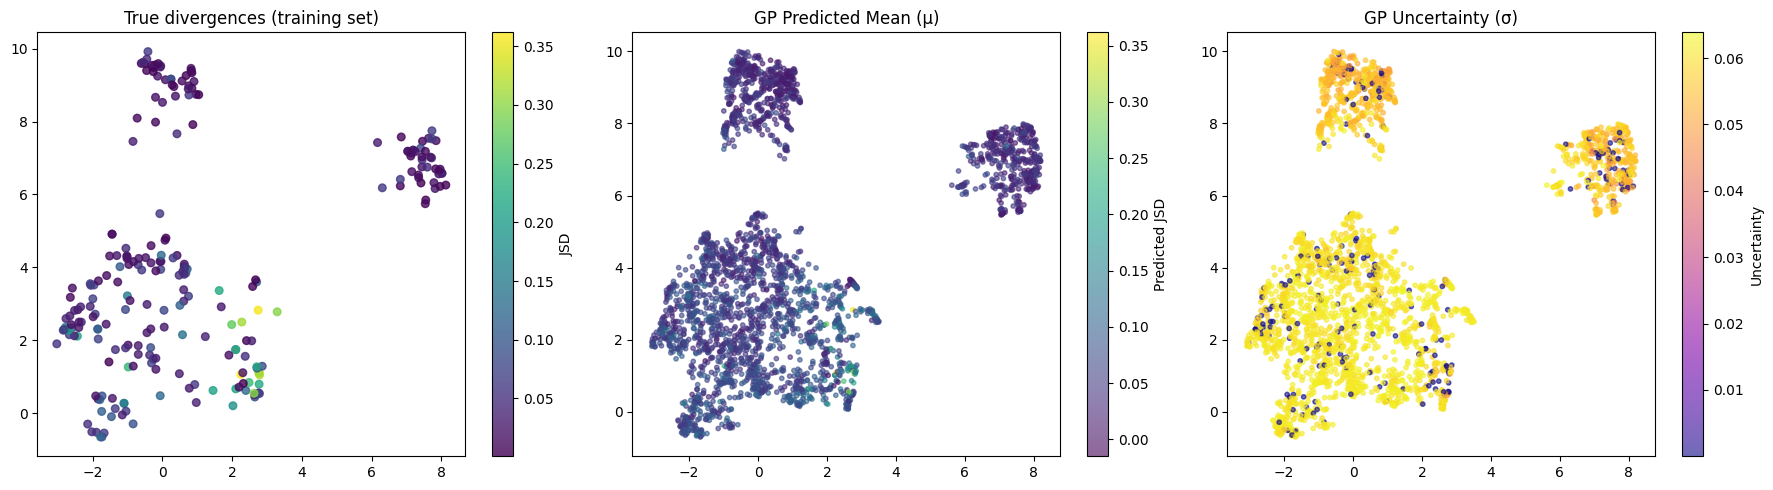

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# True divergences
axes[0].scatter(embeddings_2d[initial_indices, 0], 
                embeddings_2d[initial_indices, 1],
                c=initial_divergences, cmap='viridis', s=30, alpha=0.8)
axes[0].set_title('True divergences (training set)')
plt.colorbar(axes[0].collections[0], ax=axes[0], label='JSD')

# Predicted mean
scatter_mean = axes[1].scatter(embeddings_2d[:, 0], 
                               embeddings_2d[:, 1],
                               c=mu_all, cmap='viridis', s=10, alpha=0.6)
axes[1].set_title('GP Predicted Mean (μ)')
plt.colorbar(scatter_mean, ax=axes[1], label='Predicted JSD')

# Predicted std
scatter_std = axes[2].scatter(embeddings_2d[:, 0], 
                              embeddings_2d[:, 1],
                              c=sigma_all, cmap='plasma', s=10, alpha=0.6)
axes[2].set_title('GP Uncertainty (σ)')
plt.colorbar(scatter_std, ax=axes[2], label='Uncertainty')

plt.tight_layout()

# Acquis

In [46]:
def ucb_acquisition(mu, sigma, kappa=2.0):
    return mu + kappa * sigma

all_indices = np.arange(len(texts))
unlabeled_indices = np.setdiff1d(all_indices, initial_indices)

ucb_scores = ucb_acquisition(mu_all[unlabeled_indices], sigma_all[unlabeled_indices])

top_k = 5
top_5_local_idx = np.argsort(ucb_scores)[-top_k:][::-1]
top_5_global_idx = unlabeled_indices[top_5_local_idx]

for i, idx in enumerate(top_5_global_idx):
    print(f"  {i+1}. Text: '{texts[idx][:80]}...' | μ={mu_all[idx]:.4f}, σ={sigma_all[idx]:.4f}, UCB={ucb_scores[top_5_local_idx[i]]:.4f}")


  1. Text: 'In Greek mythology, Achilles ( ) or Achilleus () was a hero of the Trojan War wh...' | μ=0.2275, σ=0.0529, UCB=0.3333
  2. Text: 'Alcaeus of Mytilene (; , Alkaios ho Mutilēnaios;  –  BC) was a lyric poet from t...' | μ=0.1818, σ=0.0586, UCB=0.2990
  3. Text: 'Apollo or Apollon is one of the  Olympian deities in classical Greek and Roman r...' | μ=0.1782, σ=0.0586, UCB=0.2954
  4. Text: 'Actaeon (;  Aktaiōn), in Greek mythology, was the son of the priestly herdsman A...' | μ=0.1806, σ=0.0561, UCB=0.2927
  5. Text: 'Ajax ( Aias means "of the earth".) was a Greek mythological hero, son of Oileus,...' | μ=0.1795, σ=0.0560, UCB=0.2914


In [47]:
new_divergences = []
for i, idx in enumerate(top_5_global_idx):
    text = texts[idx]
    div = compute_divergence(model_a, model_b, tokenizer, text)
    new_divergences.append(div)
    print(f"  {i+1}/{top_k}: JSD = {div:.4f}")

new_divergences = np.array(new_divergences)

X_train_updated = np.vstack([X_train, embeddings[top_5_global_idx]])
y_train_updated = np.concatenate([y_train, new_divergences])

gp.fit(X_train_updated, y_train_updated)

  1/5: JSD = 0.0565
  2/5: JSD = 0.2817
  3/5: JSD = 0.5117
  4/5: JSD = 0.2038
  5/5: JSD = 0.1987


GaussianProcessRegressor(kernel=RBF(length_scale=0.5), n_restarts_optimizer=5,
                         normalize_y=True, random_state=42)

# Active search

In [48]:
budget_per_iter = 5
n_iterations = 10

# История
history = {
    'iteration': [],
    'max_divergence': [],
    'mean_divergence': [],
    'n_labeled': []
}

X_train_current = X_train.copy()
y_train_current = y_train.copy()
labeled_indices = set(initial_indices)

In [49]:
for iteration in range(n_iterations):
    print(f"\n{iteration + 1}/{n_iterations}")
    
    gp.fit(X_train_current, y_train_current)
    
    unlabeled_indices = np.array([i for i in range(len(texts)) if i not in labeled_indices])
    if len(unlabeled_indices) < budget_per_iter:
        print("Недостаточно неразмеченных точек")
        break
    
    # UCB
    mu_unlabeled, sigma_unlabeled = gp.predict(embeddings[unlabeled_indices], return_std=True)
    ucb_scores = ucb_acquisition(mu_unlabeled, sigma_unlabeled)
    
    # Top-k
    top_local = np.argsort(ucb_scores)[-budget_per_iter:][::-1]
    top_global = unlabeled_indices[top_local]
    
    # Вычисление true divergences
    new_divs = []
    for idx in top_global:
        div = compute_divergence(model_a, model_b, tokenizer, texts[idx])
        new_divs.append(div)
    
    new_divs = np.array(new_divs)
    
    # Обновление
    X_train_current = np.vstack([X_train_current, embeddings[top_global]])
    y_train_current = np.concatenate([y_train_current, new_divs])
    labeled_indices.update(top_global)
    
    # Статистика
    history['iteration'].append(iteration + 1)
    history['max_divergence'].append(y_train_current.max())
    history['mean_divergence'].append(y_train_current.mean())
    history['n_labeled'].append(len(y_train_current))
    
    print(f"  Max divergence: {y_train_current.max():.4f}")
    print(f"  Labeled: {len(y_train_current)} points")




1/10
  Max divergence: 0.5117
  Labeled: 245 points

2/10
  Max divergence: 0.5117
  Labeled: 250 points

3/10
  Max divergence: 0.5117
  Labeled: 255 points

4/10
  Max divergence: 0.5117
  Labeled: 260 points

5/10
  Max divergence: 0.5117
  Labeled: 265 points

6/10
  Max divergence: 0.5117
  Labeled: 270 points

7/10
  Max divergence: 0.5117
  Labeled: 275 points

8/10
  Max divergence: 0.5117
  Labeled: 280 points

9/10
  Max divergence: 0.5117
  Labeled: 285 points

10/10
  Max divergence: 0.5117
  Labeled: 290 points


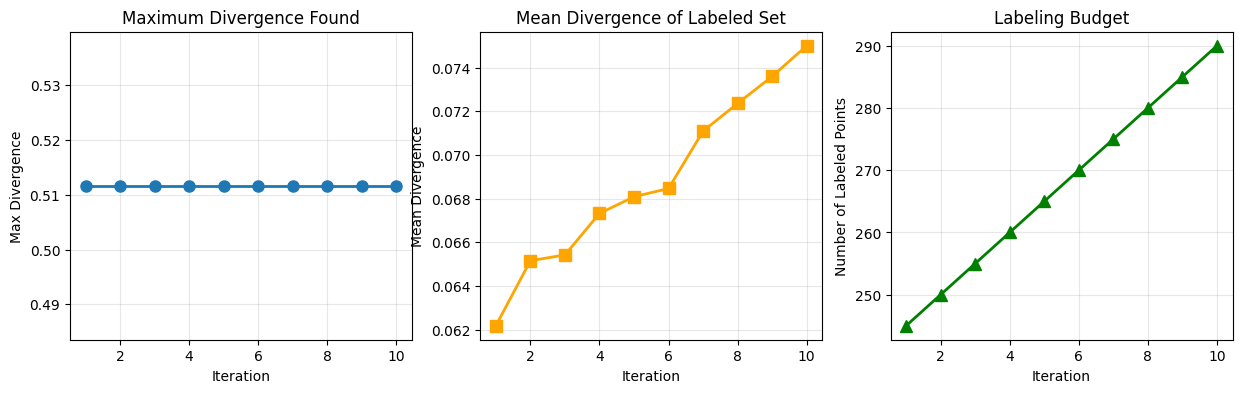

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history['iteration'], history['max_divergence'], 'o-', linewidth=2, markersize=8)
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Max Divergence')
axes[0].set_title('Maximum Divergence Found')
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['iteration'], history['mean_divergence'], 's-', linewidth=2, markersize=8, color='orange')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Mean Divergence')
axes[1].set_title('Mean Divergence of Labeled Set')
axes[1].grid(True, alpha=0.3)

axes[2].plot(history['iteration'], history['n_labeled'], '^-', linewidth=2, markersize=8, color='green')
axes[2].set_xlabel('Iteration')
axes[2].set_ylabel('Number of Labeled Points')
axes[2].set_title('Labeling Budget')
axes[2].grid(True, alpha=0.3)

# FE

In [51]:
holdout_indices = np.random.choice(
    [i for i in range(len(texts)) if i not in labeled_indices],
    size=200,
    replace=False
)

# Финальное обучение на всех размеченных
gp.fit(X_train_current, y_train_current)

# Предсказания на hold-out
mu_holdout, sigma_holdout = gp.predict(embeddings[holdout_indices], return_std=True)

# Вычисление true divergences для сравнения
true_divs_holdout = []
for i, idx in enumerate(holdout_indices):
    div = compute_divergence(model_a, model_b, tokenizer, texts[idx])
    true_divs_holdout.append(div)
    if (i + 1) % 50 == 0:
        print(f"  Hold-out progress: {i+1}/200")

true_divs_holdout = np.array(true_divs_holdout)

# Оценка teta для разных eps
epsilon_values = [0.01, 0.05, 0.10, 0.15]
theta_hats = {}

print("-" * 60)
print(f"{'eps':<10} {'teta (GP pred)':<20} {'Empirical':<20}")
print("-" * 60)

for eps in epsilon_values:
    sigma_safe = np.maximum(sigma_holdout, 1e-6)
    prob_gp = norm.cdf((eps - mu_holdout) / sigma_safe)
    theta_hat = prob_gp.mean()
    
    # Empirical
    empirical = (true_divs_holdout <= eps).mean()
    
    theta_hats[eps] = theta_hat
    print(f"{eps:<10.2f} {theta_hat:<20.4f} {empirical:<20.4f}")


  Hold-out progress: 50/200
  Hold-out progress: 100/200
  Hold-out progress: 150/200
  Hold-out progress: 200/200
------------------------------------------------------------
eps        teta (GP pred)       Empirical           
------------------------------------------------------------
0.01       0.2941               0.1050              
0.05       0.4780               0.6750              
0.10       0.7066               0.8250              
0.15       0.8708               0.9000              


(0.0, 1.0)

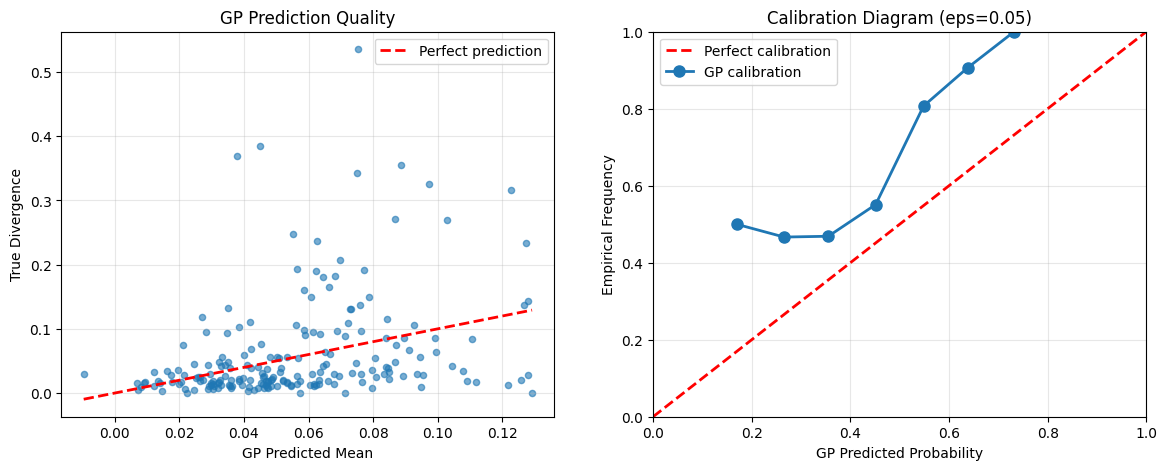

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot: predicted vs true
axes[0].scatter(mu_holdout, true_divs_holdout, alpha=0.6, s=20)
axes[0].plot([mu_holdout.min(), mu_holdout.max()], 
             [mu_holdout.min(), mu_holdout.max()], 
             'r--', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel('GP Predicted Mean')
axes[0].set_ylabel('True Divergence')
axes[0].set_title('GP Prediction Quality')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Reliability diagram для ε=0.05
eps = 0.05
sigma_safe = np.maximum(sigma_holdout, 1e-6)
prob_gp = norm.cdf((eps - mu_holdout) / sigma_safe)

# Биннинг
n_bins = 10
bin_edges = np.linspace(0, 1, n_bins + 1)
bin_indices = np.digitize(prob_gp, bin_edges) - 1
bin_indices = np.clip(bin_indices, 0, n_bins - 1)

bin_pred = []
bin_emp = []
for b in range(n_bins):
    mask = bin_indices == b
    if mask.sum() > 0:
        bin_pred.append(prob_gp[mask].mean())
        bin_emp.append((true_divs_holdout[mask] <= eps).mean())

axes[1].plot([0, 1], [0, 1], 'r--', linewidth=2, label='Perfect calibration')
axes[1].plot(bin_pred, bin_emp, 'o-', linewidth=2, markersize=8, label='GP calibration')
axes[1].set_xlabel('GP Predicted Probability')
axes[1].set_ylabel('Empirical Frequency')
axes[1].set_title(f'Calibration Diagram (eps={eps})')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1])

In [53]:
print("\n" + "=" * 70)
print("ИТОГОВАЯ КАРТА ЭКВИВАЛЕНТНОСТИ (домен: AG News)")
print("=" * 70)
print(f"Всего размечено: {len(y_train_current)} точек из {len(texts)}")
print(f"Максимальная найденная дивергенция: {y_train_current.max():.4f}")
print(f"Средняя дивергенция: {y_train_current.mean():.4f}")
print("\nОценки функциональной эквивалентности:")
for eps in epsilon_values:
    print(f"  eps= {eps:.2f}: teta= {theta_hats[eps]:.4f}")


ИТОГОВАЯ КАРТА ЭКВИВАЛЕНТНОСТИ (домен: AG News)
Всего размечено: 290 точек из 2856
Максимальная найденная дивергенция: 0.5117
Средняя дивергенция: 0.0750

Оценки функциональной эквивалентности:
  eps= 0.01: teta= 0.2941
  eps= 0.05: teta= 0.4780
  eps= 0.10: teta= 0.7066
  eps= 0.15: teta= 0.8708


# Investigation

In [54]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score
from sklearn.decomposition import PCA

print("Learned kernel:", gp.kernel_)

X_tr, y_tr = X_train_current, y_train_current
X_te, y_te = embeddings[holdout_indices], true_divs_holdout

pca = PCA(n_components=15, random_state=42).fit(embeddings)

for name, A, B in [("raw 384d", X_tr, X_te),
                   ("pca 15d",  pca.transform(X_tr), pca.transform(X_te))]:
    knn = KNeighborsRegressor(n_neighbors=5).fit(A, y_tr)
    print(f"{name}: kNN R2 = {r2_score(y_te, knn.predict(B)):.3f}")

Learned kernel: RBF(length_scale=0.694)
raw 384d: kNN R2 = 0.229
pca 15d: kNN R2 = 0.052
